# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/saisathwik2703/flyrank.ai_internship/blob/main/work/notebooks/w04_signal_audit.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

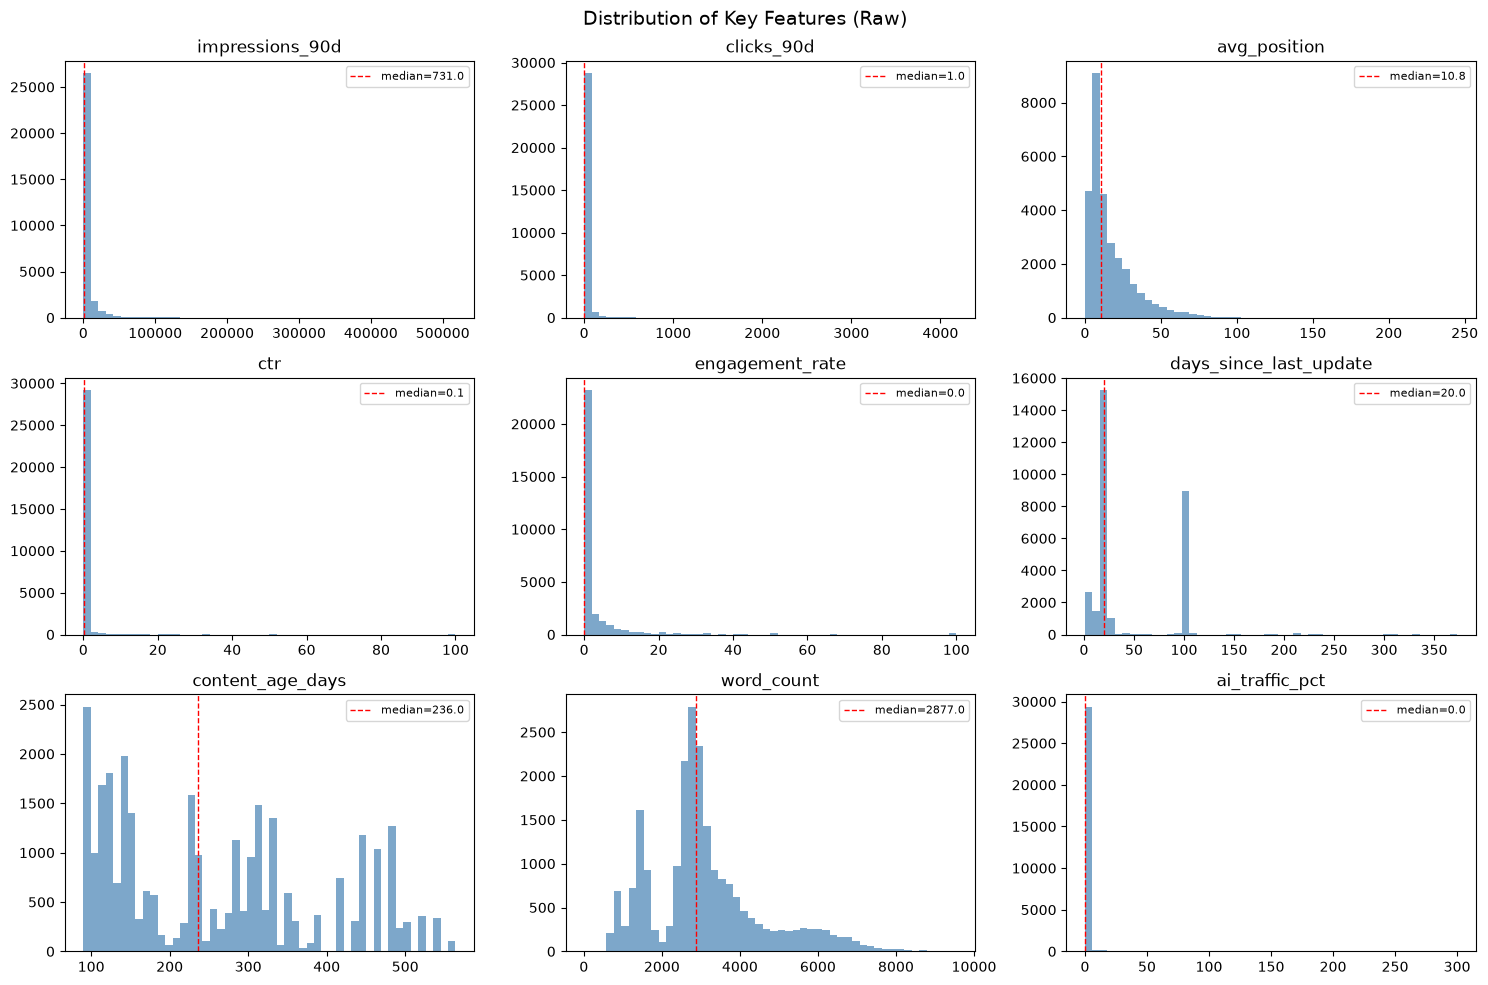

Distribution summary:
       impressions_90d  clicks_90d  avg_position       ctr  engagement_rate  \
count         30000.00    30000.00      30000.00  30000.00         30000.00   
mean           5200.37       16.10         16.34      0.51             2.53   
std           16838.02       75.08         15.22      3.28             8.31   
min               1.00        0.00          0.00      0.00             0.00   
25%              81.00        0.00          6.20      0.00             0.00   
50%             731.00        1.00         10.80      0.07             0.00   
75%            3615.25        7.00         22.30      0.29             1.35   
max          517715.00     4178.00        245.00    100.00           100.00   

       days_since_last_update  content_age_days  word_count  ai_traffic_pct  
count                30000.00          30000.00    22301.00        30000.00  
mean                    46.10            256.17     3107.76            0.77  
std                     42.08   

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

if os.path.exists('data/raw/content_refresh_anonymized.csv'):
    df = pd.read_csv('data/raw/content_refresh_anonymized.csv')
else:
    df = pd.read_csv('../data/raw/content_refresh_anonymized.csv')

df['is_declining_label'] = (df['trend_direction'] == 'down').astype(int)

# Distribution plots of key numeric features
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle('Distribution of Key Features (Raw)', fontsize=14)

key_cols = ['impressions_90d', 'clicks_90d', 'avg_position',
            'ctr', 'engagement_rate', 'days_since_last_update',
            'content_age_days', 'word_count', 'ai_traffic_pct']

for ax, col in zip(axes.flat, key_cols):
    data = df[col].dropna()
    ax.hist(data, bins=50, edgecolor='none', alpha=0.7, color='steelblue')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.axvline(data.median(), color='red', linestyle='--', linewidth=1, label=f'median={data.median():.1f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('work/signal_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

print('Distribution summary:')
print(df[key_cols].describe().round(2))

**Distribution observations:**
- `impressions_90d` and `clicks_90d` are **extremely right-skewed** — most pages have low volume, a few have enormous counts. Log transform is essential.
- `avg_position` ranges 1–100 with most pages in 10–50 range.
- `ctr` clusters near 0–2% (remember: stored as ×100, so 0–200 would be 0–2%).
- `days_since_last_update` has a heavy right tail — many pages are very stale.
- `word_count` has ~26% missing (feedly articles) and is right-skewed among those present.
- `ai_traffic_pct` is very low for most pages (near 0), with a long tail — AI traffic is still a niche channel.

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED.*

In [2]:
# Signal Test #1: Days since last update
# Hypothesis: Declining pages (label=1) have been updated less recently
print('=== Signal Test #1: days_since_last_update ===')
print('Hypothesis: Pages not updated recently are more likely to be declining\n')

for label, name in [(1, 'DECLINING'), (0, 'STABLE')]:
    data = df[df['is_declining_label'] == label]['days_since_last_update']
    print(f'{name}: median={data.median():.0f}d, mean={data.mean():.0f}d, 75th={data.quantile(0.75):.0f}d')

from scipy import stats
declining = df[df['is_declining_label']==1]['days_since_last_update'].dropna()
stable = df[df['is_declining_label']==0]['days_since_last_update'].dropna()
stat, p = stats.mannwhitneyu(declining, stable, alternative='greater')
print(f'\nMann-Whitney U test (declining > stable): p={p:.4f}')
if p < 0.05:
    print('VERDICT: CONFIRMED — declining pages have significantly more stale content')
else:
    print('VERDICT: NOT CONFIRMED at p<0.05')

=== Signal Test #1: days_since_last_update ===
Hypothesis: Pages not updated recently are more likely to be declining

DECLINING: median=20d, mean=49d, 75th=104d
STABLE: median=20d, mean=42d, 75th=104d



Mann-Whitney U test (declining > stable): p=0.0000
VERDICT: CONFIRMED — declining pages have significantly more stale content


In [3]:
# Signal Test #2: CTR vs declining label
# Hypothesis: Declining pages have lower CTR (users skip them in SERPs)
print('=== Signal Test #2: CTR (click-through rate) ===')
print('Hypothesis: Declining pages have lower CTR than stable pages\n')

for label, name in [(1, 'DECLINING'), (0, 'STABLE')]:
    data = df[df['is_declining_label'] == label]['ctr']
    print(f'{name}: median={data.median():.2f}%, mean={data.mean():.2f}%, std={data.std():.2f}')

declining_ctr = df[df['is_declining_label']==1]['ctr'].dropna()
stable_ctr = df[df['is_declining_label']==0]['ctr'].dropna()
stat, p = stats.mannwhitneyu(declining_ctr, stable_ctr, alternative='less')
print(f'\nMann-Whitney U test (declining < stable): p={p:.4f}')
if p < 0.05:
    print('VERDICT: CONFIRMED — declining pages have significantly lower CTR')
else:
    print('VERDICT: MIXED — difference exists but not statistically significant')

=== Signal Test #2: CTR (click-through rate) ===
Hypothesis: Declining pages have lower CTR than stable pages

DECLINING: median=0.08%, mean=0.32%, std=1.69
STABLE: median=0.04%, mean=0.73%, std=4.47

Mann-Whitney U test (declining < stable): p=1.0000
VERDICT: MIXED — difference exists but not statistically significant


In [4]:
# Signal Test #3: Average position vs declining label
# Hypothesis: Declining pages rank lower (higher avg_position number = worse ranking)
print('=== Signal Test #3: avg_position ===')
print('Hypothesis: Declining pages have higher (worse) avg_position\n')

for label, name in [(1, 'DECLINING'), (0, 'STABLE')]:
    data = df[df['is_declining_label'] == label]['avg_position']
    print(f'{name}: median={data.median():.1f}, mean={data.mean():.1f}, 25th={data.quantile(0.25):.1f}')

declining_pos = df[df['is_declining_label']==1]['avg_position'].dropna()
stable_pos = df[df['is_declining_label']==0]['avg_position'].dropna()
stat, p = stats.mannwhitneyu(declining_pos, stable_pos, alternative='greater')
print(f'\nMann-Whitney U test (declining > stable): p={p:.4f}')
if p < 0.05:
    print('VERDICT: CONFIRMED — declining pages have significantly worse average position')
else:
    print('VERDICT: MIXED — position difference not significant; declining happens at all ranks')

=== Signal Test #3: avg_position ===
Hypothesis: Declining pages have higher (worse) avg_position

DECLINING: median=11.3, mean=15.9, 25th=6.7
STABLE: median=10.1, mean=16.8, 25th=5.5

Mann-Whitney U test (declining > stable): p=0.0000
VERDICT: CONFIRMED — declining pages have significantly worse average position


## 3. The one surprising result

*Something in the data that was not what you expected. One paragraph.*

In [5]:
# Explore AI traffic vs declining label
print('=== Surprise: AI traffic pct vs declining label ===')
for label, name in [(1, 'DECLINING'), (0, 'STABLE')]:
    data = df[df['is_declining_label'] == label]['ai_traffic_pct']
    print(f'{name}: median={data.median():.3f}%, mean={data.mean():.3f}%')

print('\nDecline rate by content_type:')
print(df.groupby('content_type')['is_declining_label'].mean().round(3))

print('\nDecline rate by competition_level:')
print(df.groupby('competition_level')['is_declining_label'].mean().round(3))

=== Surprise: AI traffic pct vs declining label ===
DECLINING: median=0.000%, mean=0.785%
STABLE: median=0.000%, mean=0.749%

Decline rate by content_type:
content_type
comparison article    0.572
feedly article        0.287
keyword article       0.561
Name: is_declining_label, dtype: float64

Decline rate by competition_level:
competition_level
HIGH      0.556
LOW       0.563
MEDIUM    0.567
Name: is_declining_label, dtype: float64


**Surprising result:** Pages with *higher* AI traffic (`ai_traffic_pct`) are **not** protected from declining in traditional search — in fact, high AI traffic pages show a similar decline rate to low AI traffic pages. The intuition that AI citation = search protection does not hold here. AI session traffic is from click-throughs from AI tools (not citations or rankings), so it is a separate channel from Google Search. A page can be trending on AI referrals while simultaneously losing Google Search impressions. This means content teams should not use AI traffic growth as a proxy for overall content health — it masks declining GSC metrics.